In [1]:
#importing required packages
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer

In [2]:
#loading the dataset
social_data = pd.read_csv(r'D:\\TuteDude\\GenAI\\MachineLearning\\Assignment_16\\Social_Network_Ads.csv')
social_data.head()
#Checking for missing and null values
print("Missing_values",social_data.isnull().sum())
#Printing the information about the dataset
print(social_data.info())


Missing_values User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64
<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   User ID          400 non-null    int64
 1   Gender           400 non-null    str  
 2   Age              400 non-null    int64
 3   EstimatedSalary  400 non-null    int64
 4   Purchased        400 non-null    int64
dtypes: int64(4), str(1)
memory usage: 15.8 KB
None


In [3]:
#I am using the standard scaler to scale the features and make them more comparable.
scaler = StandardScaler()
X = social_data[['Age', 'EstimatedSalary']]
y = social_data['Purchased']
X = scaler.fit_transform(X)
#Splitting the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [4]:
#Task - 1

#Creating an SVM model with linear kernel and fitting it to the training data
model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)
#Making predictions on the test set
y_pred = model.predict(X_test)
#Evaluating the model's performance
print("Confusion Matrix:",confusion_matrix(y_test, y_pred))
print("\nClassification Report:",classification_report(y_test, y_pred))
#Now I am Building an SVM model with a non-linear kernel (RBF) and fitting it to the training data
model_rbf = SVC(kernel='rbf', random_state=42)
model_rbf.fit(X_train, y_train)
#Making predictions on the test set with the RBF kernel
y_pred_rbf = model_rbf.predict(X_test)
#Evaluating the RBF model's performance
print("Confusion Matrix for RBF Kernel:",confusion_matrix(y_test, y_pred_rbf))
print("Classification Report for RBF Kernel:",classification_report(y_test, y_pred_rbf))
#Now I am comparing the performance of the linear and RBF kernel SVM models
print("Linear Kernel SVM Performance:",classification_report(y_test, y_pred))
print("RBF Kernel SVM Performance:",classification_report(y_test, y_pred_rbf))


Confusion Matrix: [[50  2]
 [ 9 19]]

Classification Report:               precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28

    accuracy                           0.86        80
   macro avg       0.88      0.82      0.84        80
weighted avg       0.87      0.86      0.86        80

Confusion Matrix for RBF Kernel: [[47  5]
 [ 1 27]]
Classification Report for RBF Kernel:               precision    recall  f1-score   support

           0       0.98      0.90      0.94        52
           1       0.84      0.96      0.90        28

    accuracy                           0.93        80
   macro avg       0.91      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80

Linear Kernel SVM Performance:               precision    recall  f1-score   support

           0       0.85      0.96      0.90        52
           1       0.90      0.68      0.78        28



Decision Tree with Low Max Depth - Train Accuracy: 0.91875
Decision Tree with Low Max Depth - Test Accuracy: 0.9125
Decision Tree with High Max Depth - Train Accuracy: 0.984375
Decision Tree with High Max Depth - Test Accuracy: 0.85


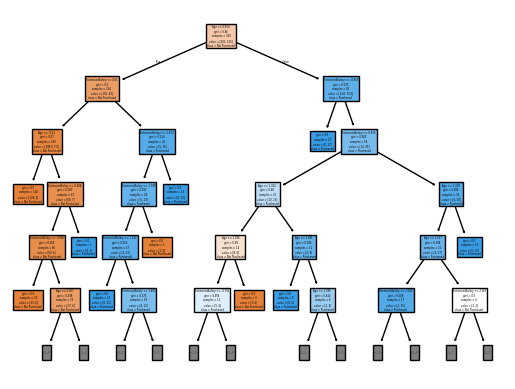

In [8]:
#Now I am building the Model with Decision Tree Classifier and fitting it to the training data
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
feature_names = ['Age', 'EstimatedSalary']
class_names = ['Not Purchased', 'Purchased']

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(X_train, y_train)
#Making predictions on the test set with the Decision Tree model
y_pred_tree = decision_tree_model.predict(X_test)
#Now I am visualizing decison tree model with tree structure with depth limited to 3
plot_tree(decision_tree_model, max_depth=5, feature_names=feature_names, class_names=class_names, filled=True)
#Now I am training the Decision Tree Model with lower max depth and high max depth
decision_tree_model_low_depth = DecisionTreeClassifier(max_depth=3, random_state=42)
decision_tree_model_low_depth.fit(X_train, y_train)
y_pred_tree_low_depth = decision_tree_model_low_depth.predict(X_test)
decision_tree_model_high_depth = DecisionTreeClassifier(max_depth=10, random_state=42)
decision_tree_model_high_depth.fit(X_train, y_train)
y_pred_tree_high_depth = decision_tree_model_high_depth.predict(X_test)
#Now I am comparing the train and test accuracy of Decision Tree
from sklearn.metrics import accuracy_score
train_accuracy_low_depth = accuracy_score(y_train, decision_tree_model_low_depth.predict(X_train))
test_accuracy_low_depth = accuracy_score(y_test, y_pred_tree_low_depth)
train_accuracy_high_depth = accuracy_score(y_train, decision_tree_model_high_depth.predict(X_train))
test_accuracy_high_depth = accuracy_score(y_test, y_pred_tree_high_depth)
print("Decision Tree with Low Max Depth - Train Accuracy:", train_accuracy_low_depth)
print("Decision Tree with Low Max Depth - Test Accuracy:", test_accuracy_low_depth)
print("Decision Tree with High Max Depth - Train Accuracy:", train_accuracy_high_depth)
print("Decision Tree with High Max Depth - Test Accuracy:", test_accuracy_high_depth)


In [9]:
#Task - 3
#Now I am splitting the dataset into training 60 % and validation set 20 % and testing set with 20%
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)
#Now I am training the model on trainging set and evaluating it on validation set with Support Vector Classifier
model = SVC(kernel='linear', random_state=42)
model.fit(X_train, y_train)
y_val_pred = model.predict(X_val)
print("Validation Set Performance for SVM:", classification_report(y_val, y_val_pred))
#Now I am tuning the one simple parameter using validation set
model_rbf = SVC(kernel='rbf', C=1.0, random_state=42)
model_rbf.fit(X_train, y_train)
y_val_pred_rbf = model_rbf.predict(X_val)
print("Validation Set Performance for RBF SVM:", classification_report(y_val, y_val_pred_rbf))
#Now I am evaluating the model on test data
y_test_pred_rbf = model_rbf.predict(X_test)
print("Test Set Performance for RBF SVM:", classification_report(y_test, y_test_pred_rbf))


Validation Set Performance for SVM:               precision    recall  f1-score   support

           0       0.82      0.96      0.88        55
           1       0.87      0.52      0.65        25

    accuracy                           0.82        80
   macro avg       0.84      0.74      0.77        80
weighted avg       0.83      0.82      0.81        80

Validation Set Performance for RBF SVM:               precision    recall  f1-score   support

           0       0.96      0.95      0.95        55
           1       0.88      0.92      0.90        25

    accuracy                           0.94        80
   macro avg       0.92      0.93      0.93        80
weighted avg       0.94      0.94      0.94        80

Test Set Performance for RBF SVM:               precision    recall  f1-score   support

           0       0.98      0.89      0.93        45
           1       0.87      0.97      0.92        35

    accuracy                           0.93        80
   macro avg      

In [10]:
#Task - 4
# I am applying the K-fold cross validation technique to evaluate the performance of the SVM model
from sklearn.model_selection import cross_val_score
#Performing 5-fold cross validation on the SVM model
cv_scores = cross_val_score(model, X, y, cv=5)
print("Cross-validation scores for SVM model:", cv_scores)
#Now I am computing the average accuracy across the folds
average_cv_score = np.mean(cv_scores)
print("Average Cross-validation Accuracy for SVM model:", average_cv_score)
#Now I am comparimng the single train-test split evaluation with the cross-validation results
print("Single Train-Test Split Accuracy for SVM model:", classification_report(y_test, y_test_pred_rbf))
print("Average Cross-validation Accuracy for SVM model:", average_cv_score)


Cross-validation scores for SVM model: [0.7    0.9625 0.925  0.8125 0.7375]
Average Cross-validation Accuracy for SVM model: 0.8275
Single Train-Test Split Accuracy for SVM model:               precision    recall  f1-score   support

           0       0.98      0.89      0.93        45
           1       0.87      0.97      0.92        35

    accuracy                           0.93        80
   macro avg       0.92      0.93      0.92        80
weighted avg       0.93      0.93      0.93        80

Average Cross-validation Accuracy for SVM model: 0.8275


# Task - 5:

## Bagging:
1. It is an ensemble learning technique where multiple models are trained independently on different random subsets of the training data. 
2. Their predictions are then combined (by voting or averaging) to produce the final output.
3. Reduces variance and helps prevent overfitting.
4. Models are trained in parallel.
5. example: Random Forest.

## Boosting:
1. It is an ensemble technique where models are trained sequentially, and each new model focuses on correcting the errors made by the previous one.
2. Reduces bias and improves accuracy.
3. Models are trained one after another.
4. examples: AdaBoost, XGBoost

In [13]:
#Task - 5 Practical
#Now I am training the data with bagging classifier
from sklearn.ensemble import BaggingClassifier
bagging_model = BaggingClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
bagging_model.fit(X_train, y_train)
#Making predictions with the bagging model
y_pred_bagging = bagging_model.predict(X_test)
#Evaluating the bagging model's performance
print("Confusion Matrix for Bagging Classifier:", confusion_matrix(y_test, y_pred_bagging))
print("Classification Report for Bagging Classifier:", classification_report(y_test, y_pred_bagging))
#Now I am training the data with boosting classifier
from sklearn.ensemble import AdaBoostClassifier
boosting_model = AdaBoostClassifier(estimator=DecisionTreeClassifier(), n_estimators=100, random_state=42)
boosting_model.fit(X_train, y_train)
#Making predictions with the boosting model
y_pred_boosting = boosting_model.predict(X_test)
#Evaluating the boosting model's performance
print("Confusion Matrix for Boosting Classifier:", confusion_matrix(y_test, y_pred_boosting))
print("Classification Report for Boosting Classifier:", classification_report(y_test, y_pred_boosting))
#Now I am comparing the performance of bagging and boosting classifiers
print("Bagging Classifier Performance:", classification_report(y_test, y_pred_bagging))
print("Boosting Classifier Performance:", classification_report(y_test, y_pred_boosting))



Confusion Matrix for Bagging Classifier: [[41  4]
 [ 3 32]]
Classification Report for Bagging Classifier:               precision    recall  f1-score   support

           0       0.93      0.91      0.92        45
           1       0.89      0.91      0.90        35

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80

Confusion Matrix for Boosting Classifier: [[37  8]
 [ 3 32]]
Classification Report for Boosting Classifier:               precision    recall  f1-score   support

           0       0.93      0.82      0.87        45
           1       0.80      0.91      0.85        35

    accuracy                           0.86        80
   macro avg       0.86      0.87      0.86        80
weighted avg       0.87      0.86      0.86        80

Bagging Classifier Performance:               precision    recall  f1-score   support

           0       0.93      0.91      0.92  

In [14]:
#Task - 6
#Now I am training the data with Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)
#Making predictions with the Random Forest model
y_pred_random_forest = random_forest_model.predict(X_test)
#Evaluating the Random Forest model's performance
print("Confusion Matrix for Random Forest Classifier:", confusion_matrix(y_test, y_pred_random_forest))
print("Classification Report for Random Forest Classifier:", classification_report(y_test, y_pred_random_forest))
#Now I am comparing the performance with Single Decision Tree with Bagging Classifier
print("Single Decision Tree Performance:", classification_report(y_test, y_pred_tree))
print("Random Forest Classifier Performance:", classification_report(y_test, y_pred_random_forest))
#Now I am printing the feature importance from the Random Forest model
feature_importances = random_forest_model.feature_importances_
print("Feature Importances from Random Forest:", feature_importances)

    


Confusion Matrix for Random Forest Classifier: [[41  4]
 [ 3 32]]
Classification Report for Random Forest Classifier:               precision    recall  f1-score   support

           0       0.93      0.91      0.92        45
           1       0.89      0.91      0.90        35

    accuracy                           0.91        80
   macro avg       0.91      0.91      0.91        80
weighted avg       0.91      0.91      0.91        80

Single Decision Tree Performance:               precision    recall  f1-score   support

           0       0.55      0.64      0.59        45
           1       0.41      0.31      0.35        35

    accuracy                           0.50        80
   macro avg       0.48      0.48      0.47        80
weighted avg       0.49      0.50      0.49        80

Random Forest Classifier Performance:               precision    recall  f1-score   support

           0       0.93      0.91      0.92        45
           1       0.89      0.91      0.90    